Bibliotecas e dados

In [7]:
import kagglehub
import os
import pandas as pd

# Download latest version
dataset_path = kagglehub.dataset_download("ayessa/salary-prediction-classification")

for file in os.listdir(dataset_path):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(dataset_path, file))
        break

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)


Análise Exploratória de Dados

In [9]:
# Verificando dados
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [11]:
#Tipos de Dados e Informações
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  salary          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [12]:
# Verificando valores faltantes
print(df.isnull().sum())


age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
salary            0
dtype: int64


In [13]:
print(df['salary'].value_counts(normalize=True))

salary
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64


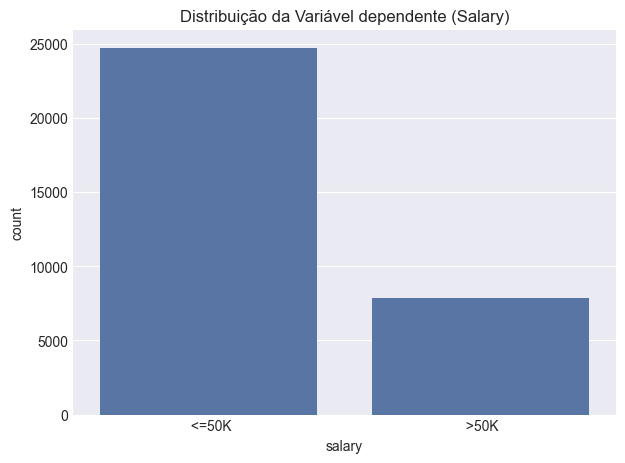

In [ ]:
#Distribuição da variável dependente
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='salary')
plt.title('Distribuição da Variável dependente (Salary)')
plt.show()

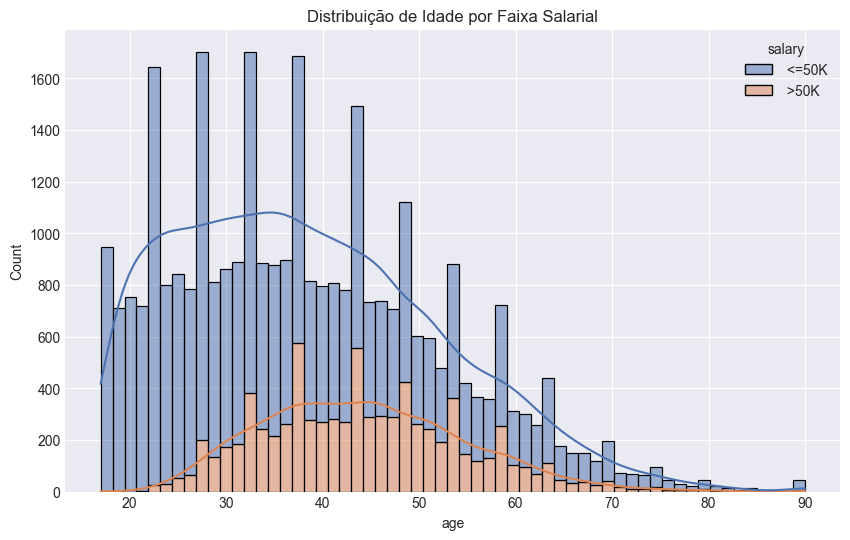

In [16]:
#Histograma da idade por faixa salarial
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='salary', kde=True, multiple='stack')
plt.title('Distribuição de Idade por Faixa Salarial')
plt.show()


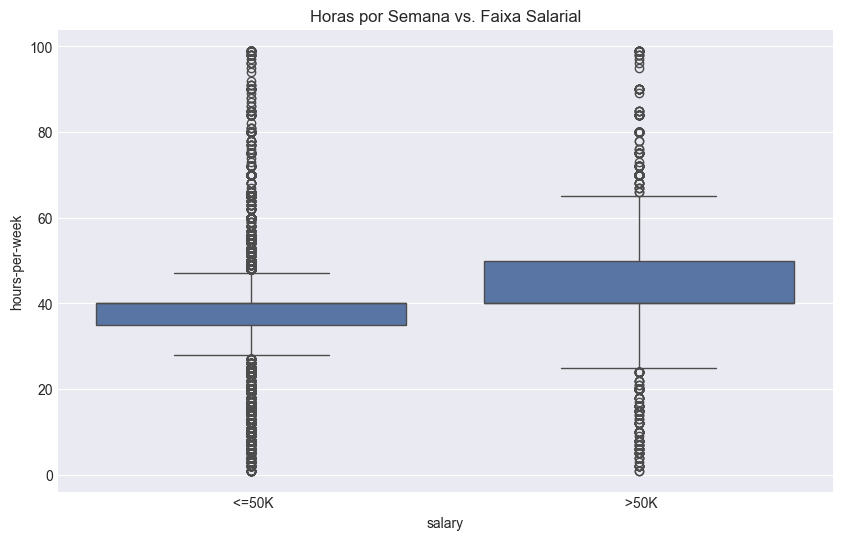

In [17]:
#Boxplot de Horas por Semana
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='salary', y='hours-per-week')
plt.title('Horas por Semana vs. Faixa Salarial')
plt.show()

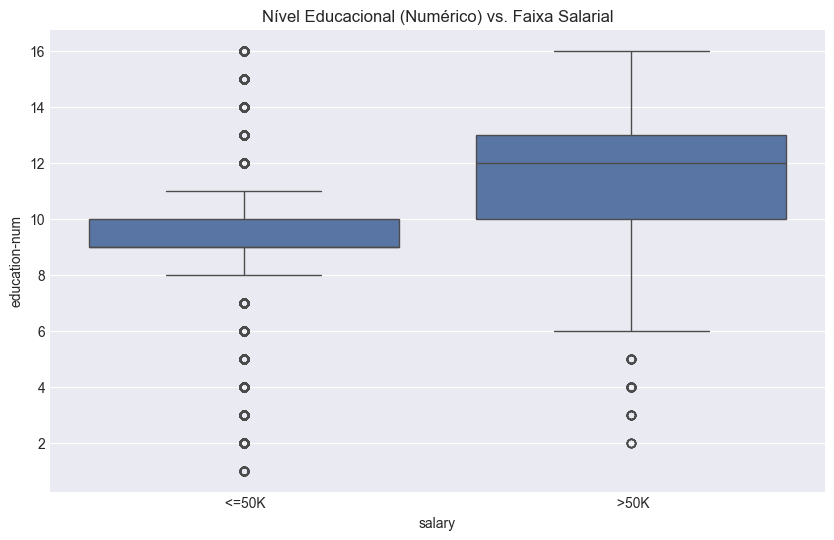

In [20]:
#Nível Educacional
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='salary', y='education-num')
plt.title('Nível Educacional (Numérico) vs. Faixa Salarial')
plt.show()

Pré-processamento dos Dados

In [21]:
df_clean = df

# Criar a variável alvo binária (1 para >50K, 0 para <=50K)
df_clean['target'] = (df_clean['salary'].str.strip() == '>50K').astype(int)

In [23]:
# Selecionar features (X) e alvo (y)
# Removemos a 'salary' original, 'education' (redundante) e 'fnlwgt' (não é feature)
features_to_drop = ['salary', 'education', 'fnlwgt']
X = df_clean.drop(columns=features_to_drop + ['target'])
y = df_clean['target']

In [25]:
# Identificar colunas numéricas e categóricas
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

In [26]:
print(f"\nFeatures Numéricas: {list(numeric_features)}")
print(f"Features Categóricas: {list(categorical_features)}")


Features Numéricas: ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Features Categóricas: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [ ]:
# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, #30% para teste
    random_state=42, 
    stratify=y # Usar stratify=y devido ao desbalanceamento de classe
)
print(f"\nDivisão dos dados: {X_train.shape[0]} treino, {X_test.shape[0]} teste")


Divisão dos dados: 22792 treino, 9769 teste


Regressão Linear

In [ ]:
# 1. Para numéricas: StandardScaler
# 2. Para categóricas: OneHotEncoder (ignora desconhecidos, drop='first' para evitar multicolinearidade)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ])

In [30]:
# Criar o pipeline final com o modelo de Regressão Linear
pipeline_linear = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [31]:
# Treinar o modelo
pipeline_linear.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [32]:
# Fazer previsões
y_pred_linear_cont = pipeline_linear.predict(X_test)

Avaliação

In [56]:
#Para comparar, aplicamos um limiar (threshold) de 0.5

#Dessa forma, se a previsão for > 0.5, se encaixa na categoria ">50K"
#Se for <= 0.5, se encaixa na categoria "<=50K"
y_pred_linear_class = (y_pred_linear_cont > 0.5).astype(int)

print("Avaliação (Métricas de Classificação):")
print(classification_report(y_test, y_pred_linear_class, target_names=['<=50K', '>50K']))

auc_lpm = roc_auc_score(y_test, y_pred_linear_cont)

print(f"  AUC-ROC Score (LPM): {auc_lpm:.4f}")

Avaliação (Métricas de Classificação):
              precision    recall  f1-score   support

       <=50K       0.86      0.94      0.90      7417
        >50K       0.74      0.53      0.61      2352

    accuracy                           0.84      9769
   macro avg       0.80      0.73      0.76      9769
weighted avg       0.83      0.84      0.83      9769

  AUC-ROC Score (LPM): 0.8953


Regressão Logística

In [42]:
pipeline_logistic = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

In [43]:
# Treinar o modelo
pipeline_logistic.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
# Fazer previsões
y_pred_logistic_class = pipeline_logistic.predict(X_test)
y_pred_logistic_proba = pipeline_logistic.predict_proba(X_test)[:, 1] # Probabilidade da classe 1


Avaliação Regressão Logística

In [47]:
print("Avaliação (Métricas de Classificação):")
print(classification_report(y_test, y_pred_logistic_class, target_names=['<=50K', '>50K']))

print(f"  AUC-ROC Score: {roc_auc_score(y_test, y_pred_logistic_proba):.4f}")


Avaliação (Métricas de Classificação):
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      7417
        >50K       0.73      0.61      0.67      2352

    accuracy                           0.85      9769
   macro avg       0.81      0.77      0.79      9769
weighted avg       0.85      0.85      0.85      9769

  AUC-ROC Score: 0.9084


Avaliação Regressão Linear

In [57]:
print(classification_report(y_test, y_pred_linear_class, target_names=['<=50K', '>50K']))
print(f"  AUC-ROC Score (LPM): {auc_lpm:.4f}")

              precision    recall  f1-score   support

       <=50K       0.86      0.94      0.90      7417
        >50K       0.74      0.53      0.61      2352

    accuracy                           0.84      9769
   macro avg       0.80      0.73      0.76      9769
weighted avg       0.83      0.84      0.83      9769

  AUC-ROC Score (LPM): 0.8953


Comparação entre modelos

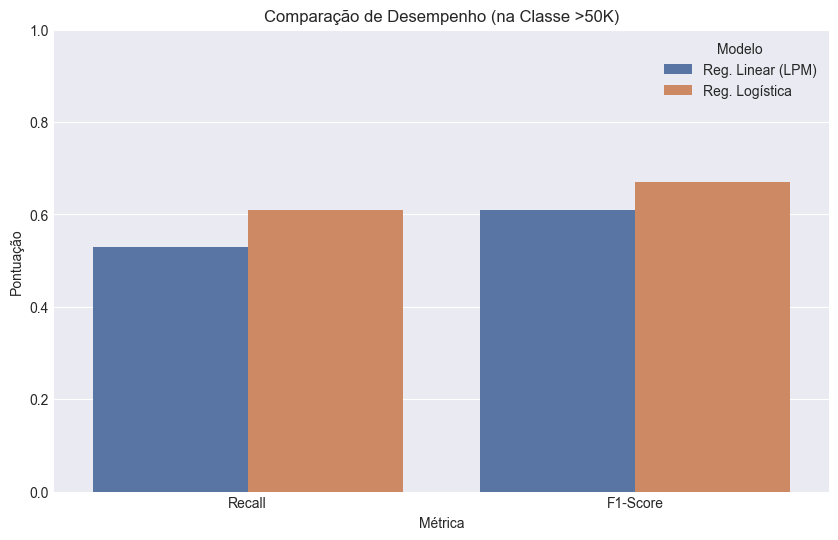

In [61]:
#Principal diferença entre os modelos foi o Recall e F1-Score na Classe >50K
metrics_data = {
    'Modelo': ['Reg. Linear (LPM)', 'Reg. Logística', 'Reg. Linear (LPM)', 'Reg. Logística'],
    'Métrica': ['Recall', 'Recall', 'F1-Score', 'F1-Score'],
    'Pontuação': [0.53, 0.61, 0.61, 0.67]
}
df_metrics = pd.DataFrame(metrics_data)

# Plotar o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_metrics, 
    x='Métrica', 
    y='Pontuação', 
    hue='Modelo'
)

plt.title('Comparação de Desempenho (na Classe >50K)')
plt.ylim(0, 1.0) # Define o eixo Y de 0 a 1
plt.show()